In [1]:
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
import qiskit_optimization

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

for package in [
    "qiskit",
    "qiskit-aer",
    "qiskit-optimization",
    "numpy",
    "pandas",
]:
    print(f"{package}: {version(package)}")

Python executable: c:\Users\Khiem\anaconda3\envs\nt409-khiem\python.exe
Python version: 3.12.14
qiskit: 2.5.2
qiskit-aer: 0.17.2
qiskit-optimization: 0.7.0
numpy: 2.5.3
pandas: 3.0.6


Kết quả đo: {'00': 521, '11': 503}
Tổng số lần đo: 1024


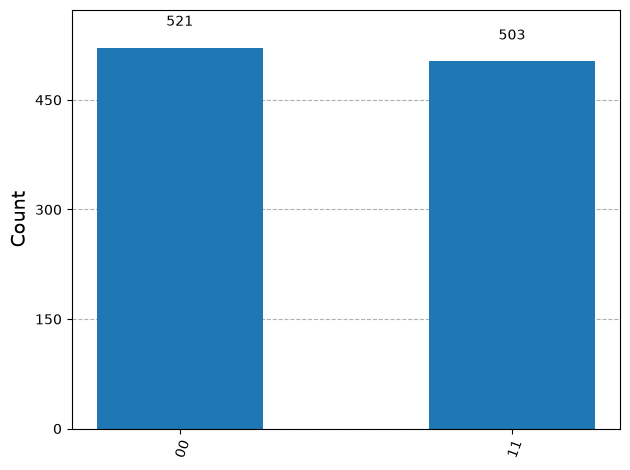

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

SEED = 42
SHOTS = 1024

circuit = QuantumCircuit(2)

circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()

simulator = AerSimulator()

compiled_circuit = transpile(
    circuit,
    simulator,
    seed_transpiler=SEED,
)

result = simulator.run(
    compiled_circuit,
    shots=SHOTS,
    seed_simulator=SEED,
).result()

counts = result.get_counts()

print("Kết quả đo:", counts)
print("Tổng số lần đo:", sum(counts.values()))

display(plot_histogram(counts))